# West Bengal Election Result Analysis

This notebook uses the CSV files in the DataSets folder to analyze party and alliance performance, winning margins, and constituency-level patterns for the West Bengal election dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_theme(style='whitegrid')

base = Path('DataSets')
alliance_df = pd.read_csv(base / 'WestBengal2026Election_Alliance.csv')
metadata_df = pd.read_csv(base / 'WestBengal2026Election_Constituency_Metadata.csv')
details_df = pd.read_csv(base / 'WestBengal2026Election_Details.csv')

print('Alliance data shape:', alliance_df.shape)
print('Metadata shape:', metadata_df.shape)
print('Details shape:', details_df.shape)


Alliance data shape: (5, 4)
Metadata shape: (294, 8)
Details shape: (1764, 11)


Merged rows: (1764, 16)
Winning candidates: 294
           Constituency                         Party  Total_Votes  Vote_Share
0             Mekliganj  All India Trinamool Congress        45397       26.78
6           Mathabhanga        Bharatiya Janata Party        49827       25.53
12    Cooch Behar Uttar        Bharatiya Janata Party        72260       34.28
18  Cooch Behar Dakshin        Bharatiya Janata Party        76203       36.73
24           Sitalkuchi  All India Trinamool Congress        72474       32.39

Seat share by party:
Party
All India Trinamool Congress          132
Bharatiya Janata Party                 98
Indian National Congress               37
Communist Party of India (Marxist)     18
None of the Above                       9
Name: count, dtype: int64

Average winning vote share by party:
Party
All India Trinamool Congress          36.746212
Bharatiya Janata Party                33.037143
Indian National Congress              30.435676
Communist Party of India (

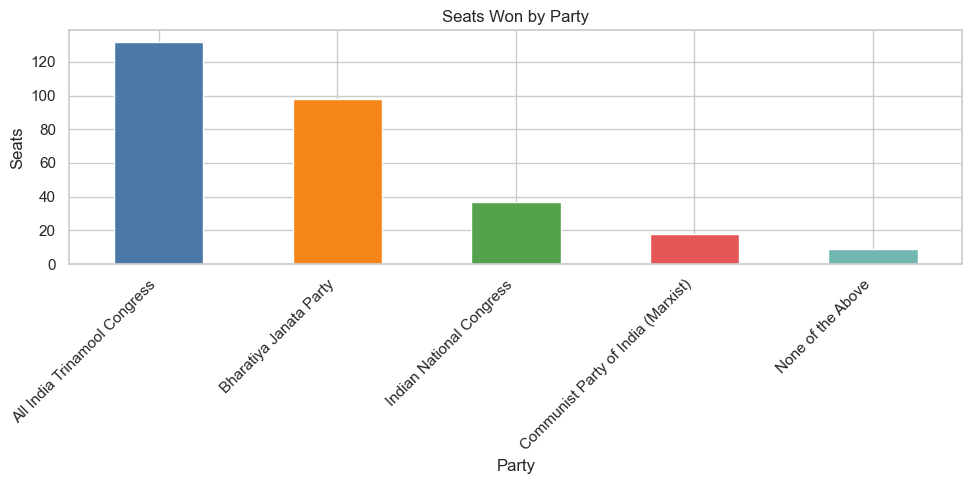

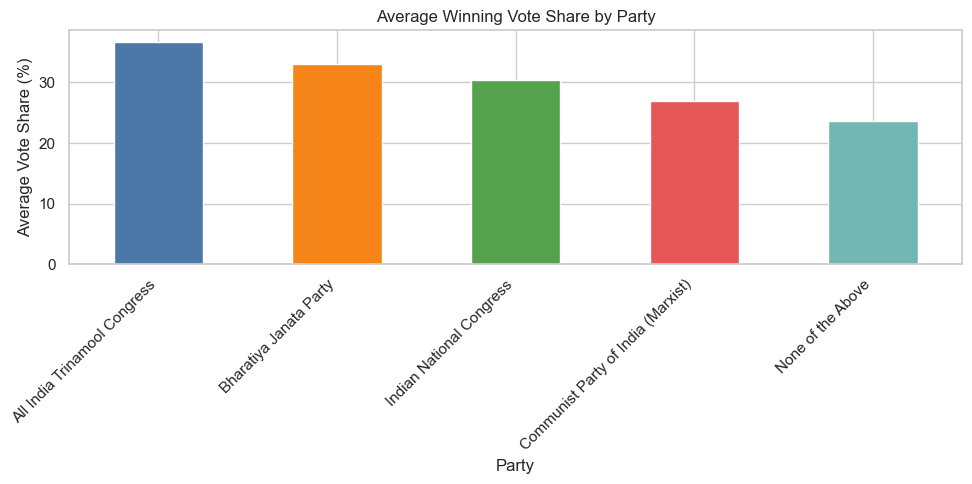


Reserved vs General seats:
Reserved
GENERAL     93
SC          96
ST         105
dtype: int64


In [ ]:
# Clean and merge the datasets
for df in [metadata_df, details_df]:
    for col in ['Tot_Constituency_votes_polled', 'Tot_votes_by_parties', 'Winning_votes', 'Total_Votes', 'EVM_Votes', 'Postal_Votes']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

merged_df = details_df.merge(
    metadata_df[['Constituency', 'District', 'Reserved', 'Lok_sabha_constituency']],
    on='Constituency',
    how='left'
)
merged_df['Winner'] = merged_df['Win_Lost_Flag'].astype(str).str.strip().str.lower().eq('true')
merged_df['Vote_Share'] = (merged_df['Total_Votes'] / merged_df['Tot_Constituency_votes_polled'] * 100).round(2)
merged_df['Margin'] = (merged_df['Winning_votes'] - merged_df['Total_Votes']).abs().round(0)

winners_df = merged_df[merged_df['Winner']].copy()
print('Merged rows:', merged_df.shape)
print('Winning candidates:', winners_df.shape[0])
print(winners_df[['Constituency', 'Party', 'Total_Votes', 'Vote_Share']].head())

# 1) Party-wise seat share
seat_share = winners_df['Party'].value_counts().head(10)
print('\nSeat share by party:')
print(seat_share)

# 2) Average vote share by party for winners
avg_vote_share = winners_df.groupby('Party')['Vote_Share'].mean().sort_values(ascending=False).head(10)
print('\nAverage winning vote share by party:')
print(avg_vote_share)

# 3) District-level winning distribution
district_seats = winners_df['District'].value_counts().head(10)
print('\nTop districts by winning seats:')
print(district_seats)

# 4) Winning margins by constituency
margin_summary = winners_df[['Constituency', 'District', 'Party', 'Margin', 'Vote_Share']].sort_values('Margin').head(15)
print('\nTightest winning margins:')
print(margin_summary.to_string(index=False))

# 5) Alliance-level summary using the alliance mapping file
alliance_map = alliance_df[['ALLIANCE_NAME', 'PARTY_FULL_NAME']].copy()
alliance_map = alliance_map.rename(columns={'ALLIANCE_NAME': 'Alliance', 'PARTY_FULL_NAME': 'Party'})
alliance_summary = winners_df.merge(alliance_map, on='Party', how='left')
alliance_seats = alliance_summary['Alliance'].fillna('Independent/Other').value_counts()
print('\nSeats by alliance:')
print(alliance_seats)

# Visual 1: Seats won by party
plt.figure(figsize=(10, 5))
seat_share.plot(kind='bar', color=['#4C78A8', '#F58518', '#54A24B', '#E45756', '#72B7B2'])
plt.title('Seats Won by Party')
plt.ylabel('Seats')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visual 2: Average winning vote share
plt.figure(figsize=(10, 5))
avg_vote_share.plot(kind='bar', color=['#4C78A8', '#F58518', '#54A24B', '#E45756', '#72B7B2'])
plt.title('Average Winning Vote Share by Party')
plt.ylabel('Average Vote Share (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visual 3: Winning seats by district
plt.figure(figsize=(12, 6))
district_seats.plot(kind='bar', color='#4C78A8')
plt.title('Winning Seats by District')
plt.ylabel('Seats')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visual 4: Distribution of winning vote share
plt.figure(figsize=(8, 4))
sns.histplot(winners_df['Vote_Share'], bins=15, kde=True, color='#54A24B')
plt.title('Distribution of Winning Vote Share')
plt.xlabel('Vote Share (%)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Executive summary text
print('\nExecutive Summary')
print('-----------------')
print(f"The dataset contains {merged_df['Constituency'].nunique()} constituencies and {winners_df.shape[0]} winning candidates.")
print(f"The leading party by seats is {seat_share.index[0]} with {seat_share.iloc[0]} seats.")
print(f"The highest average winning vote share is recorded by {avg_vote_share.index[0]} at {avg_vote_share.iloc[0]:.2f}%.")
print(f"The tightest winning margin in the data is {margin_summary.iloc[0]['Constituency']} with a margin of {margin_summary.iloc[0]['Margin']} votes.")
print('District-level patterns suggest that a small number of districts account for a large share of winning seats.')
